In [1]:
print("AH")

AH


In [2]:
!pip install einx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.0/103.0 kB 5.6 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn as nn
from torch.optim import SGD
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
import os
import torchvision.transforms as transforms
import json
import einx

from tqdm import tqdm

In [4]:


class COCOObjectDetectionDataset(Dataset):
    def __init__(self, image_dir, annotation_file, transform=None):
        self.image_dir = image_dir
        self.transform = transform or transforms.ToTensor()

        # Load annotations
        with open(annotation_file, 'r') as f:
            data = json.load(f)

        # Hardcode COCO fruit category IDs
        fruit_category_ids = {52, 53, 55}  # banana, apple, orange

        # Map image_id → file_name
        self.imgs = {img['id']: img['file_name'] for img in data['images']}

        # Build mapping: image_id → (bbox, label) for fruit categories only
        self.image_instances = {}
        for ann in tqdm(data['annotations']):
            if ann['category_id'] not in fruit_category_ids:
                continue  # skip non-fruit annotations
            img_id = ann['image_id']
            bbox = ann['bbox']
            label = ann['category_id']
            if img_id not in self.image_instances:
                self.image_instances[img_id] = []
            self.image_instances[img_id].append((bbox, label))

        # Keep only images that contain fruit annotations
        self.image_ids = list(self.image_instances.keys())

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_path = os.path.join(self.image_dir, self.imgs[img_id])
        image = Image.open(img_path).convert('RGB')
        target = self.image_instances[img_id]

        boxes = [x[0] for x in target]
        labels = [x[1] for x in target]

        if self.transform:
            image = self.transform(image)
        return image, np.array(boxes), labels
        
def get_category_names(annotation_file):
    with open(annotation_file, 'r') as f:
        data = json.load(f)
    return {cat['id']: cat['name'] for cat in data['categories']}
    


train_images_dir = '/kaggle/input/coco-2017-dataset/coco2017/train2017'
train_annotation_file = '/kaggle/input/coco-2017-dataset/coco2017/annotations/instances_train2017.json'
category_names = get_category_names(train_annotation_file)
train_ds = COCOObjectDetectionDataset(train_images_dir, train_annotation_file)


100%|██████████| 860001/860001 [00:00<00:00, 3591371.83it/s]


In [5]:
img, boxes, labels = train_ds[10]
print(boxes)

[[225.48 176.66  50.31  39.08]
 [239.48  90.61  18.51  13.65]]


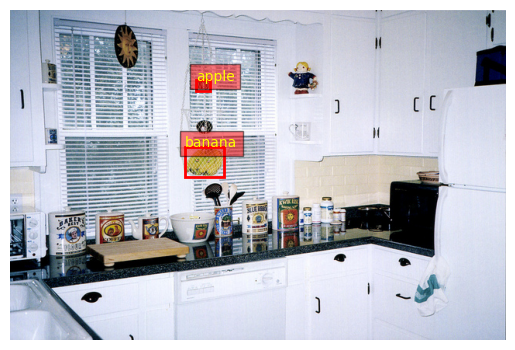

In [6]:
def plotImg(img, boxes, labels):

    img_np = einx.rearrange("c h w -> h w c", img).numpy()
    fig, ax = plt.subplots(1)
    ax.imshow(img_np)
    
    for box, label_id in zip(boxes, labels):
        x, y, w, h = box
        rect = plt.Rectangle((x, y), w, h, fill=False, color='red', linewidth=2)
        ax.add_patch(rect)
        # Draw category name on the box
        label_name = category_names[label_id]
        ax.text(x, y, label_name, fontsize=10, color='yellow',
                bbox=dict(facecolor='red', alpha=0.5))
    
    plt.axis('off')
    plt.show()
plotImg(img, boxes, labels)


In [7]:
from functools import partial

# Depending on how we architect our model, we will want to transform our 
# ground truth data into a grid of (HeightCells, WidthCells) and for each cell
# find what bounding boxes that should be associated with that cell


# To make the math with bounding boxes and intersections over unions much easier, 
# our model will predict these normalized values. But it will become much easier to calculate
# the IOU if we work in pixel space for both the ground truth and our predictions
# So, along with a normalized bounding box, here's a function which can take as input
# that normalized bounding box and conver it to pixel space.
# HINT!: This function can also be used to turn an arbitrary model prediction back into pixel space

def unnormalizeBBox(normalizedBBox, numVerticalCells, numHorizontalCells, cellYIdx, cellXIdx, imgHeight, imgWidth):
    # if normalizedBBox is a tensor, detach it and make it a numpy array
    if hasattr(normalizedBBox, "detach"):
        normalizedBBox = normalizedBBox.detach().cpu().numpy()
    cellWidth = imgWidth / numHorizontalCells
    cellHeight = imgHeight / numVerticalCells
    centerXPixelspace = normalizedBBox[0] * cellWidth + cellXIdx * cellWidth
    centerYPixelspace = normalizedBBox[1] * cellHeight + cellYIdx * cellHeight
    pixelWidth = normalizedBBox[2] * imgHeight
    pixelHeight = normalizedBBox[3] * imgWidth
    return np.array([centerXPixelspace, centerYPixelspace, pixelWidth, pixelHeight])
    
def prepareGroundTruth(img, boxes, labels, numVertCells, numHorizontalCells):
    cellH = (img.shape[1] / numVertCells)
    cellW = (img.shape[2] / numHorizontalCells)
    bboxArray = [[[] for _ in range(numHorizontalCells)] for _ in range(numVertCells)]
    for box in boxes:
        boxCenterWidth = box[0] + box[2] / 2
        boxCenterHeight = box[1] + box[3] / 2

        # Get which cell the bounding box should be placed in 
        cellHeightIdx = int(boxCenterHeight // cellH)
        cellWidthIdx = int(boxCenterWidth // cellW)

        # normalize box width/height by img dim
        # normalize center to be offset relative to cell top left corner 

        normalizedCenterX = (boxCenterWidth - cellWidthIdx * cellW) / cellW
        normalizedCenterY = (boxCenterHeight - cellHeightIdx * cellH) / cellH
        normalizedWidth = box[2] / img.shape[2]
        normalizedHeight = box[3] / img.shape[1]

        normalizedBBox = np.array([normalizedCenterX, normalizedCenterY, normalizedWidth, normalizedHeight])
        
        
        bboxArray[cellHeightIdx][cellWidthIdx].append(normalizedBBox)
        
    return bboxArray

numVerticalCells, numHorizontalCells = 3, 3

# Passing 3, 3 in as arguments splits the image up into cells like a tic-tac-toe board
arr = prepareGroundTruth(img, boxes, labels, numVerticalCells, numHorizontalCells)

# arr[1][1] gets a list of all the bounding boxes whose centers are in the middle cell
arr[1][1]

[array([0.17485156, 0.38169014, 0.07860938, 0.09173709])]

In [8]:
cellYIdx, cellXIdx = 1, 1

firstBoundingBoxMiddleCell = arr[cellYIdx][cellXIdx][0]
print(firstBoundingBoxMiddleCell)

# As you can see, applying our function brings us back nicely into pixel space
# Here the list is, in pixels, [centerX, centerY, width, height]

print(unnormalizeBBox(firstBoundingBoxMiddleCell, 
                      numVerticalCells, 
                      numHorizontalCells, 
                      cellYIdx, 
                      cellXIdx, 
                      img.shape[1], 
                      img.shape[2]))

[0.17485156 0.38169014 0.07860938 0.09173709]
[250.635      196.2         33.48759375  58.71173709]


In [9]:
# Given two arbitrary boxes in pixel space where each box
# is represented by [centerX, centerY, width, height],
# calculate the intersection over union of the two boxes
# should always return a float between 0 and 1
def IOU(pixelSpaceBox1, pixelSpaceBox2):
    # pixelSpaceBox coordinates array = [x, y, w, h]
    
    # convert center coords to corner corners (top left and bottom right)
    # box 1
    left_x_1 = pixelSpaceBox1[0] - (pixelSpaceBox1[2] / 2)
    top_y_1 = pixelSpaceBox1[1] - (pixelSpaceBox1[3] / 2)
    right_x_1 = pixelSpaceBox1[0] + (pixelSpaceBox1[2] / 2)
    bot_y_1 = pixelSpaceBox1[1] + (pixelSpaceBox1[3] / 2)
    

    # box 2
    left_x_2 = pixelSpaceBox2[0] - (pixelSpaceBox2[2] / 2)
    top_y_2 = pixelSpaceBox2[1] - (pixelSpaceBox2[3] / 2)
    right_x_2 = pixelSpaceBox2[0] + (pixelSpaceBox2[2] / 2)
    bot_y_2 = pixelSpaceBox2[1] + (pixelSpaceBox2[3] / 2)


    # find intersection boundaries
    left_edge_x = max(left_x_1, left_x_2)
    right_edge_x = min(right_x_1, right_x_2)
    top_edge_y = max(top_y_1, top_y_2)
    bot_edge_y = min(bot_y_1, bot_y_2)
    intersectWidth = max(0, right_edge_x - left_edge_x)
    intersectHeight = max(0, bot_edge_y - top_edge_y)
    
    # intersection area
    intersection_area = intersectWidth * intersectHeight

    # area of union (sum of both box areas minus intersection)
    area_box_1 = pixelSpaceBox1[2] * pixelSpaceBox1[3]
    area_box_2 = pixelSpaceBox2[2] * pixelSpaceBox2[3]
    area_of_union = (area_box_1 + area_box_2) - intersection_area

    # IOU = area of intersection / area of union
    IOU = intersection_area / area_of_union
    return float(IOU)


In [10]:


def YOLOLossSingleCell(singleCellGroundTruthList,
                        singleCellPredictionArr,
                        numVerticalCells,
                         numHorizontalCells, 
                         cellYIdx, 
                         cellXIdx, 
                         imgHeight, 
                         imgWidth):
    # For each of the trueIndices, we need to store which predIdx is the best predictor for it.
    # denomalizingFn turns coords to absolute pixels
    # predIdx index for bbox pred being evaluated
    # predBBox ^^ corresponding bbox pred [x, y, w, h, confidence]

    bestPredForGroundTruth = {}
    indicesOfResponsiblePredBoundingBoxes = set()

    for trueIdx, trueNormalizedBBox in enumerate(singleCellGroundTruthList):
        truePixelBbox = unnormalizeBBox(trueNormalizedBBox,
                                        numVerticalCells,
                                        numHorizontalCells,
                                        cellYIdx,
                                        cellXIdx,
                                        imgHeight,
                                        imgWidth)
        maxIOU = -np.inf # float
        bestPredIdx = -np.inf
        for predIdx, predBBox in enumerate(singleCellPredictionArr):
            predPixelBbox = unnormalizeBBox(predBBox[:4], # only x,y,w,h
                                            numVerticalCells,
                                            numHorizontalCells,
                                            cellYIdx,
                                            cellXIdx,
                                            imgHeight,
                                            imgWidth)
            # compute IOU between truePixelBbox and predPixelBbox
            currentIOU = IOU(truePixelBbox, predPixelBbox)
            if currentIOU > maxIOU:
                maxIOU = currentIOU
                bestPredIdx = predIdx

        # store tuple in array -- does this mean you'll have a bunch of unnecessary tuples?
        # what are the edge cases for this im confused
        bestPredForGroundTruth[trueIdx] = (bestPredIdx, maxIOU)
        indicesOfResponsiblePredBoundingBoxes.add(bestPredIdx)

    total_local_loss = 0
    total_confidence_obj_loss = 0
    # add one for classification loss obj


    # starter code from alan didn't include trueIdx, added it to alter to my answer
    # just for note in case i fuck up smth then at least i remember lol <3
    for trueIdx, trueNormalizedBBox in enumerate(singleCellGroundTruthList):
        responsible_predIdx, curr_maxIOU = bestPredForGroundTruth[trueIdx]
        bestCellPrediction = singleCellPredictionArr[responsible_predIdx]

        # apply sigmoid function (going from neg inifinity to infinity to 0 and 1 in way that makes sense) *****
        
        # math math lots of math
        # need coords from true and responsible pred bbox
        (true_x, true_y, true_w, true_h) = trueNormalizedBBox
        (pred_x, pred_y, pred_w, pred_h, pred_C) = bestCellPrediction

        # COORDINATION/LOCALIZATION LOSS FUNCTION
            # same for responsible -- need to minimize squares
        lambda_coord = 5 # 2.2 training
        # center loss equation
        localize_loss_xy = (pred_x - true_x)**2 + (pred_y - true_y)**2
            # doesn't matter order bc u square
        
        # DIMENSION/SIZE loss equation TAKE SQUAREROOT
        localize_loss_wh = (pred_w ** 0.5 - true_w ** 0.5)**2 + \
            (pred_h ** 0.5 - true_h ** 0.5)**2
        # total local loss var = ^^ sum of 2 * lambda coord (5)
        total_local_loss = lambda_coord * (localize_loss_xy + localize_loss_wh)

        # CONFIDENCE OBJECT LOSS FUNCTION -- for object present
        # no lambda needed
        # c hat = max iou achieved (why) = curr_maxIOU
        # confidence loss obj do math c - c_hat quant squared
        # add to total_confidence_obj_loss
        total_confidence_obj_loss += (pred_C - curr_maxIOU)**2

        # confidence obj loss func -- for no object
        # lambda noobj = 0.5
        # lambda_noobj = 0.5 # 2.2 training
            # iterate through all the bboxes then if curr one is not responsible
                # can you use bestPredIdx[i] or smth like that to find responsible ones
                # or create another array in prev for loop just to track best predIdx
            # then set confidence score = 0 --> (0 - curr_maxIOU)^2
            # extract pred confidence c equal to curr

        # confidence no obj loss use for loop BELOW
        # drag toward zero
        # need term: c hat = pred_c, c is the iou --> use curr_maxIOU
    

    # for NON responsible
    for predIdx, predBBox in enumerate(singleCellPredictionArr):
        lambda_noobj = 0.5
        if predIdx not in indicesOfResponsiblePredBoundingBoxes:
            pred_C_noobj = predBBox[4] # confidence score
            total_confidence_obj_loss += lambda_noobj * (pred_C_noobj - 0)**2


        # classification loss???
        # how tf do u get pi and pi_c_hat
        # probability Pr(class | object)
    return total_local_loss + total_confidence_obj_loss

In [11]:
import torch

def calcFullLoss(predictionBboxes, groundTruthBboxes, 
                 numHorizontalGridCells = 30, numVerticalGridCells = 30,
                imageHeight = 224, imageWidth=224):
    loss = torch.tensor(0.)
    for cellYIdx, gridRow in enumerate(groundTruthBboxes):
        for cellXIdx, singleCellGroundTruthList in enumerate(gridRow):
            lossForCell = YOLOLossSingleCell(singleCellGroundTruthList,
                                             predictionBboxes[cellYIdx][cellXIdx],
                                             numHorizontalGridCells,
                                             numVerticalGridCells,
                                             cellYIdx,
                                             cellXIdx,
                                             imageHeight,
                                             imageWidth)
            loss += lossForCell
    return loss

# Example, 3 by 3 grid

exampleGroundTruthBboxes = [
    [[], [], []],
    [[], [np.array([-0.25, 0.25, 0.5, 0.5])], []],
    [[], [], []]
]

examplePredictionBboxes = torch.rand(3, 3, 2, 5)

calcFullLoss(examplePredictionBboxes, exampleGroundTruthBboxes, 3, 3)

tensor(7.6470)

In [12]:
exampleBestPredictionBboxes = examplePredictionBboxes.clone()
exampleBestPredictionBboxes[:, :, :, -1] = 0
exampleBestPredictionBboxes[1, 1, 0, :-1] = torch.tensor(exampleGroundTruthBboxes[1][1])
exampleBestPredictionBboxes[1, 1, 0, -1] = 1.0

calcFullLoss(exampleBestPredictionBboxes, exampleGroundTruthBboxes, 3, 3)

/tmp/ipykernel_13/1830563515.py:3: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  exampleBestPredictionBboxes[1, 1, 0, :-1] = torch.tensor(exampleGroundTruthBboxes[1][1])


tensor(0.)

In [13]:
import torch

exampleGroundTruthBboxes = [
    [[np.array([-0.7, -0.7, 0.5, 0.5])], [], []],
    [[], [np.array([-0.25, 0.25, 0.5, 0.5])], []],
    [[], [], []]
]

# Dummy prediction tensor with gradient tracking
predictionsWithGrad = torch.rand(3, 3, 2, 5, requires_grad=True)

optimizer = torch.optim.Adam([predictionsWithGrad], lr=0.1)
for step in range(200):
    optimizer.zero_grad()                    
    loss = calcFullLoss(predictionsWithGrad, exampleGroundTruthBboxes, 3, 3)
    loss.backward()                          
    optimizer.step()                         
print("All Final predictions:")
print("""Notice that the confidences are 0 for 
all bounding boxes except one of the two bounding boxes
in the cell that matches our dummy data. In this cell
we have one of the boxes perfectly match our ground truth data.""")
print(predictionsWithGrad.round(decimals=4))
print()
print("Bounding Box Predictions In Grid Cell (1, 1):")
print(predictionsWithGrad[1, 1].round(decimals=4))


All Final predictions:
Notice that the confidences are 0 for 
all bounding boxes except one of the two bounding boxes
in the cell that matches our dummy data. In this cell
we have one of the boxes perfectly match our ground truth data.
tensor([[[[-7.0000e-01, -7.0000e-01,  5.0000e-01,  5.0000e-01,  9.9980e-01],
          [ 4.8960e-01,  7.0670e-01,  1.1500e-01,  7.0920e-01, -0.0000e+00]],

         [[ 3.6430e-01,  9.9500e-02,  8.7250e-01,  7.9540e-01,  0.0000e+00],
          [ 6.0490e-01,  2.4000e-02,  4.9500e-01,  8.9040e-01, -0.0000e+00]],

         [[ 6.5050e-01,  9.9200e-01,  9.0450e-01,  5.9660e-01,  0.0000e+00],
          [ 4.6430e-01,  6.6210e-01,  5.5100e-02,  9.9760e-01, -0.0000e+00]]],


        [[[ 7.8130e-01,  3.8640e-01,  9.9180e-01,  7.0950e-01,  0.0000e+00],
          [ 9.9620e-01,  6.1190e-01,  3.1200e-02,  5.4880e-01, -0.0000e+00]],

         [[ 3.5320e-01,  8.5320e-01,  2.8020e-01,  5.4830e-01, -0.0000e+00],
          [-2.5000e-01,  2.5000e-01,  5.0000e-01,  5.0000e-01

In [14]:
# Define a pytorch dataset where the __getitem__(self, idx) function returns both an image (normalized to, for example, 224 by 224 pixels)
# So shape: (3, 224, 224)
# and a ground truth data that looks kind of like exampleGroundTruthBboxes above. Note that the function
# prepareGroundTruth(img, boxes, labels, numVerticalCells, numHorizontalCells) that I provided in the codestem
# process the coco data into this format very easily given the img, boxes, labels variables returned by my stem dataset

In [15]:
import einx
# Define a convolutional neural network which takes in an image of of shape
# (3, 224, 224) and outputs a tensor of shape (numVerticalGridCells, numHorizontalGridCells, numBoundingBoxesPerGridCell, 5)
# A Conv2d Layer takes you from an image of shape (channelsIn, height, width) -> (channelsOut, heightOut, widthOut)
# Instead use the neural network to go from (as in the paper):
# (3, 224, 224) -> (numChannelsOut, heightOut, widthOut)
# (3, 224, 224) -> (5 * numBoundingBoxesPerCell, numVerticalGridCells, numHorizontalGridCells)


# After the neural network output, reshape to the proper size:
# einx.rearrange("(B d) S_V S_H -> S_V S_H B d", modelOutput)

exampleModelOutput = torch.rand(5 * 2, 3, 3)
print(exampleModelOutput.shape)

transformedModelOutput = einx.rearrange("(B d) S_V S_H -> S_V S_H B d", exampleModelOutput,
                                        B = 2, d=5, S_V=3, S_H = 3)
print(transformedModelOutput.shape)

torch.Size([10, 3, 3])
torch.Size([3, 3, 2, 5])
